In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROUND_NUM = 3
BASE = '.'
DAYS = ['0', '1', '2']

# Load all price data
frames = []
trade_frames = []
for day in DAYS:
    df = pd.read_csv(f'{BASE}/round3/prices_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    trade_df = pd.read_csv(f'{BASE}/round3/trades_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    
    df['abs_ts'] = df['timestamp'] + int(day) * 1_000_000
    trade_df['abs_ts'] = trade_df['timestamp'] + int(day) * 1_000_000
    trade_df['day'] = int(day)
    frames.append(df)
    trade_frames.append(trade_df)

prices = pd.concat(frames, ignore_index=True)
trades = pd.concat(trade_frames, ignore_index=True)

products = sorted(prices['product'].unique())
print(f'Products: {products}')
print(f'Days: {DAYS}  |  Total rows: {len(prices)}')

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Days: ['0', '1', '2']  |  Total rows: 360000


In [2]:
pack = prices[prices['product'] == "HYDROGEL_PACK"]
pack_trades = trades[trades['symbol'] == 'HYDROGEL_PACK']

In [3]:
pack.head(3)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,abs_ts
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0
19,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,100
24,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,200


In [4]:
pack_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,abs_ts,day
7,8000,NaN,NaN,HYDROGEL_PACK,XIRECS,10018.0,6,8000,0
10,10100,NaN,NaN,HYDROGEL_PACK,XIRECS,10014.0,5,10100,0
18,15300,NaN,NaN,HYDROGEL_PACK,XIRECS,10026.0,3,15300,0
20,15700,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,2,15700,0
21,16400,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,4,16400,0
...,...,...,...,...,...,...,...,...,...
4029,984700,NaN,NaN,HYDROGEL_PACK,XIRECS,9984.0,5,2984700,2
4033,992200,NaN,NaN,HYDROGEL_PACK,XIRECS,10029.0,4,2992200,2
4035,993200,NaN,NaN,HYDROGEL_PACK,XIRECS,10024.0,6,2993200,2
4042,994800,NaN,NaN,HYDROGEL_PACK,XIRECS,10011.0,4,2994800,2


In [5]:
pack['mid_price'].mean()

np.float64(9990.806866666666)

In [6]:
pack_trades['timestamp'].value_counts()
# pack_trades[pack_trades['abs_ts'] == 596100]
# pack_trades[pack_trades['timestamp'] == 502000]
# pack_trades[pack_trades['timestamp'] == 501600]
# 501400    2
# 206200    2

timestamp
221200    2
185800    2
502000    2
193400    2
335300    2
         ..
64300     1
65400     1
65900     1
69500     1
996500    1
Name: count, Length: 986, dtype: int64

In [7]:
pack['fair'] = pack['mid_price'] * 0.9 + 0.1 * 9990

/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_36861/2402691524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pack['fair'] = pack['mid_price'] * 0.9 + 0.1 * 9990


/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_36861/229194468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pack['spread'] = pack['ask_price_1'] - pack['bid_price_1']


(array([  275.,   490.,   225.,     0.,     0.,     0.,     0.,     0.,
          798., 28212.]),
 array([ 7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17.]),
 <BarContainer object of 10 artists>)

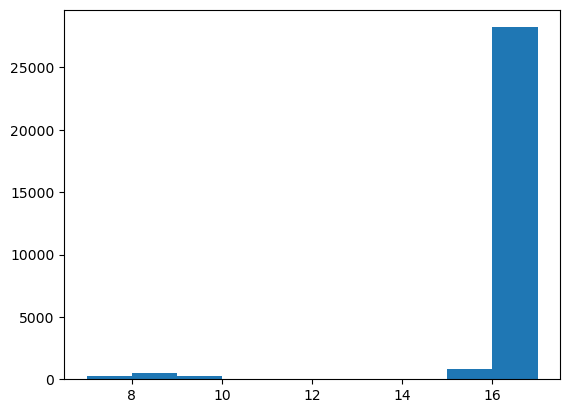

In [8]:
pack['spread'] = pack['ask_price_1'] - pack['bid_price_1']
plt.hist(pack['spread'])

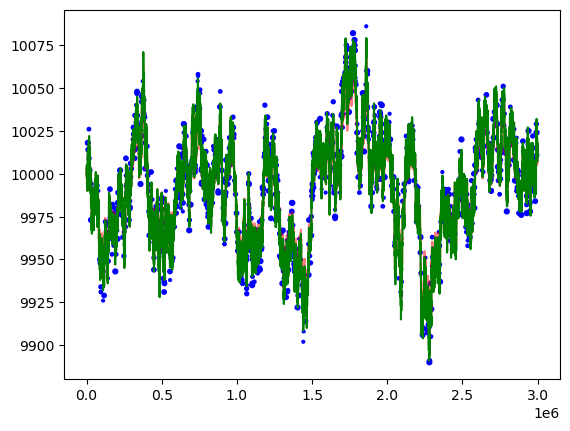

In [9]:
plt.plot(pack['abs_ts'], pack['fair'], color="red", alpha=0.5)
plt.plot(pack['abs_ts'], pack['mid_price'], color="green")
plt.scatter(pack_trades['abs_ts'], pack_trades['price'], s=2 * pack_trades['quantity'], c="blue")

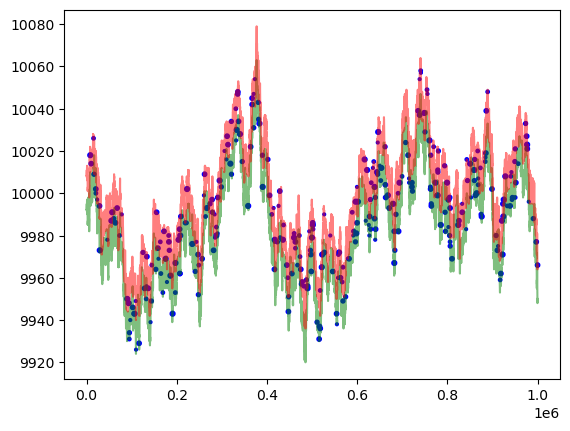

In [10]:
day1_pack = pack[pack['day'] == 0]
day1_trades = pack_trades[pack_trades['day'] == 0]

plt.plot(day1_pack['abs_ts'], day1_pack['bid_price_1'], color="green", alpha=0.5)
plt.plot(day1_pack['abs_ts'], day1_pack['ask_price_1'], color="red", alpha=0.5)
plt.scatter(day1_trades['abs_ts'], day1_trades['price'], s=2 * day1_trades['quantity'], c="blue")

## Mid Price PDF + Mean Reversion Analysis

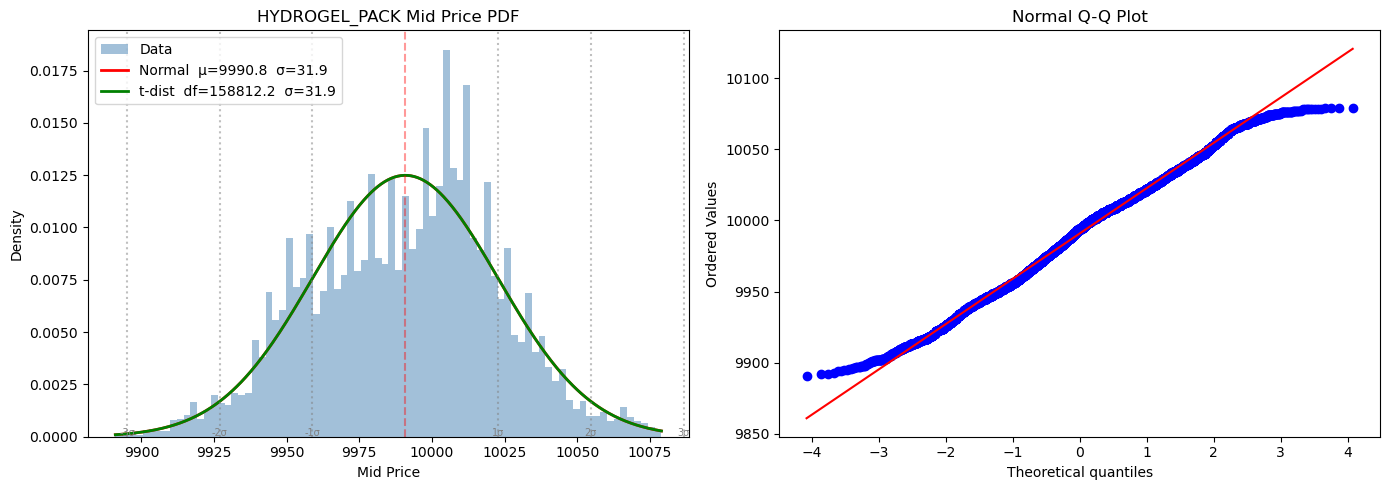

μ = 9990.81,  σ = 31.93
Skew     = -0.1116
Kurtosis = -0.3098  (excess; normal=0)
K-S p    = 2.6020e-63  (non-normal)

Std dev levels:
  -3σ → price = 9895.0
  -2σ → price = 9926.9
  -1σ → price = 9958.9
  +0σ → price = 9990.8
  +1σ → price = 10022.7
  +2σ → price = 10054.7
  +3σ → price = 10086.6


In [11]:
from scipy import stats

mid = pack['mid_price'].values

mu_fit, std_fit = stats.norm.fit(mid)
df_t, loc_t, scale_t = stats.t.fit(mid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(mid, bins=80, density=True, alpha=0.5, color='steelblue', label='Data')
x = np.linspace(mid.min(), mid.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu_fit, std_fit), 'r-', lw=2,
        label=f'Normal  μ={mu_fit:.1f}  σ={std_fit:.1f}')
ax.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), 'g-', lw=2,
        label=f't-dist  df={df_t:.1f}  σ={scale_t:.1f}')
for s in [-3, -2, -1, 1, 2, 3]:
    ax.axvline(mu_fit + s * std_fit, color='gray', linestyle=':', alpha=0.5)
    ax.text(mu_fit + s * std_fit, ax.get_ylim()[1] * 0.001, f'{s}σ', ha='center', fontsize=7, color='gray')
ax.axvline(mu_fit, color='red', linestyle='--', alpha=0.4)
ax.set_xlabel('Mid Price')
ax.set_ylabel('Density')
ax.set_title('HYDROGEL_PACK Mid Price PDF')
ax.legend()

ax = axes[1]
stats.probplot(mid, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

ks_stat, ks_p = stats.kstest(mid, 'norm', args=(mu_fit, std_fit))
print(f"μ = {mu_fit:.2f},  σ = {std_fit:.2f}")
print(f"Skew     = {stats.skew(mid):.4f}")
print(f"Kurtosis = {stats.kurtosis(mid):.4f}  (excess; normal=0)")
print(f"K-S p    = {ks_p:.4e}  ({'likely normal' if ks_p > 0.05 else 'non-normal'})")
print(f"\nStd dev levels:")
for s in [-3, -2, -1, 0, 1, 2, 3]:
    print(f"  {s:+d}σ → price = {mu_fit + s*std_fit:.1f}")

## Mean Reversion Characterization (OU Process)

ADF Statistic: -5.1584
p-value:       1.0685e-05  (stationary (mean-reverting))

OU κ (mean-reversion speed): 0.00230 per tick
Half-life: 301 ticks  =  30.1 seconds


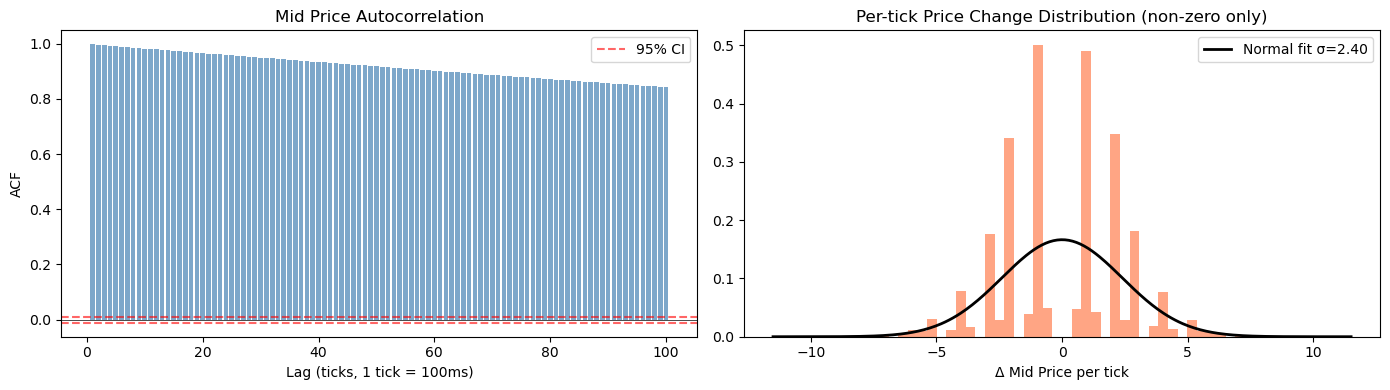


Typical tick move (non-zero): 2.40 ticks
Fraction of ticks with no price move: 18.0%


In [12]:
from statsmodels.tsa.stattools import adfuller, acf

mid_s = pd.Series(mid)

# ADF test
adf = adfuller(mid_s, autolag='AIC')
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value:       {adf[1]:.4e}  ({'stationary (mean-reverting)' if adf[1] < 0.05 else 'NOT stationary'})")

# OU half-life via OLS on Δp = α + β*p_{t-1}
delta = mid_s.diff().dropna().values
lag   = mid_s.shift(1).dropna().values
X     = np.column_stack([np.ones_like(lag), lag])
beta  = np.linalg.lstsq(X, delta, rcond=None)[0]
half_life_ticks = -np.log(2) / beta[1]
half_life_sec   = half_life_ticks * 100 / 1000
print(f"\nOU κ (mean-reversion speed): {-beta[1]:.5f} per tick")
print(f"Half-life: {half_life_ticks:.0f} ticks  =  {half_life_sec:.1f} seconds")

# Autocorrelation plot
acf_vals = acf(mid_s, nlags=100)[1:]
conf = 1.96 / np.sqrt(len(mid_s))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(np.arange(1, 101), acf_vals, color='steelblue', alpha=0.7)
ax.axhline(conf,  color='red', linestyle='--', alpha=0.6, label='95% CI')
ax.axhline(-conf, color='red', linestyle='--', alpha=0.6)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Lag (ticks, 1 tick = 100ms)')
ax.set_ylabel('ACF')
ax.set_title('Mid Price Autocorrelation')
ax.legend()

# Δprice distribution — shows the per-tick move size
ax = axes[1]
delta_all = np.diff(mid)
ax.hist(delta_all[delta_all != 0], bins=60, density=True, color='coral', alpha=0.7)
mu_d, std_d = stats.norm.fit(delta_all[delta_all != 0])
x_d = np.linspace(delta_all.min(), delta_all.max(), 300)
ax.plot(x_d, stats.norm.pdf(x_d, mu_d, std_d), 'k-', lw=2, label=f'Normal fit σ={std_d:.2f}')
ax.set_xlabel('Δ Mid Price per tick')
ax.set_title('Per-tick Price Change Distribution (non-zero only)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nTypical tick move (non-zero): {std_d:.2f} ticks")
print(f"Fraction of ticks with no price move: {(delta_all == 0).mean():.1%}")

## Target Position Curve

Target position as a function of price. Uses `tanh` so it's zero at μ, saturates at ±POS_LIMIT, and scales smoothly.

`target(p) = -POS_LIMIT × tanh(z / k)` where `z = (p − μ) / σ`

- **k small** → aggressive (big positions at small deviations)
- **k large** → conservative (reserves room until extreme moves)

Goal: at 1σ hold ~30–50% of max, saturate by 2.5–3σ.

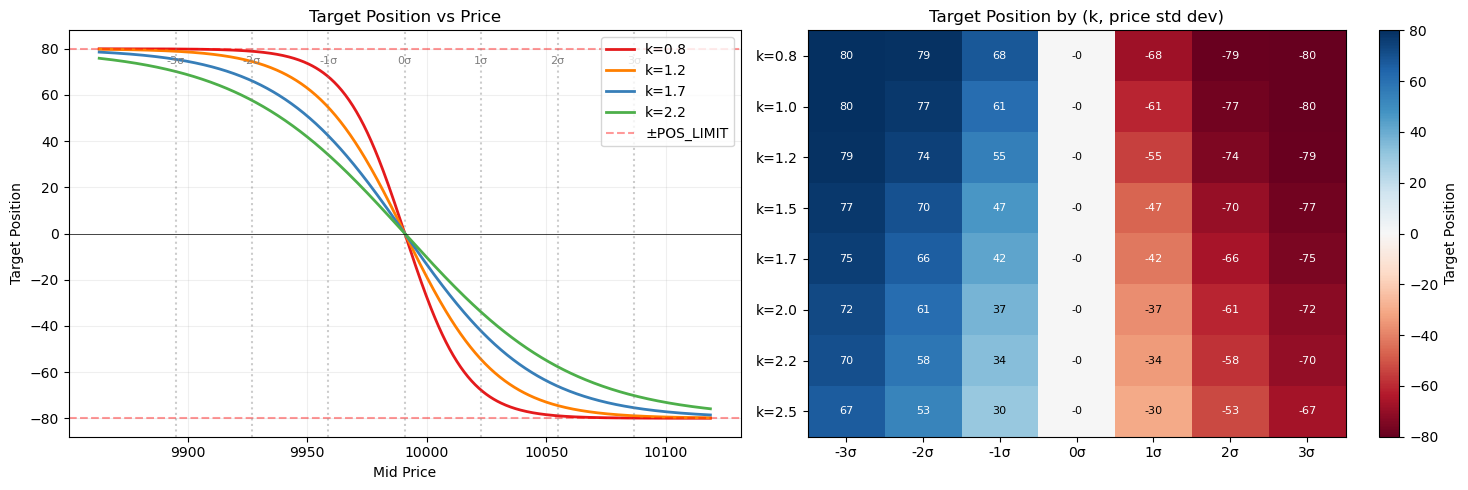

Target positions at k=1.5:
  -3σ  price=9895  target=+77.1  (96% of limit)
  -2σ  price=9927  target=+69.6  (87% of limit)
  -1σ  price=9959  target=+46.6  (58% of limit)
  +0σ  price=9991  target= -0.0  (0% of limit)
  +1σ  price=10023  target=-46.6  (58% of limit)
  +2σ  price=10055  target=-69.6  (87% of limit)
  +3σ  price=10087  target=-77.1  (96% of limit)


In [13]:
POS_LIMIT = 80
PACK_MEAN = mu_fit
PACK_STD  = std_fit

p_range = np.linspace(PACK_MEAN - 4 * PACK_STD, PACK_MEAN + 4 * PACK_STD, 500)
z_range = (p_range - PACK_MEAN) / PACK_STD

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: target position curves for several k values ---
ax = axes[0]
ks_to_show = [0.8, 1.2, 1.7, 2.2]
colors = ['#e41a1c', '#ff7f00', '#377eb8', '#4daf4a']
for k, c in zip(ks_to_show, colors):
    target = -POS_LIMIT * np.tanh(z_range / k)
    ax.plot(p_range, target, color=c, lw=2, label=f'k={k}')

ax.axhline(0, color='black', lw=0.5)
ax.axhline( POS_LIMIT, color='red', linestyle='--', alpha=0.4, label='±POS_LIMIT')
ax.axhline(-POS_LIMIT, color='red', linestyle='--', alpha=0.4)
for s in [-3, -2, -1, 0, 1, 2, 3]:
    ax.axvline(PACK_MEAN + s * PACK_STD, color='gray', linestyle=':', alpha=0.4)
    ax.text(PACK_MEAN + s * PACK_STD, POS_LIMIT * 0.92, f'{s}σ', ha='center', fontsize=8, color='gray')
ax.set_xlabel('Mid Price')
ax.set_ylabel('Target Position')
ax.set_title('Target Position vs Price')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# --- Right: position table heatmap ---
ax = axes[1]
k_vals = np.array([0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.2, 2.5])
sigma_vals = np.array([-3, -2, -1, 0, 1, 2, 3])
table = np.array([[-POS_LIMIT * np.tanh(s / k) for s in sigma_vals] for k in k_vals])

im = ax.imshow(table, cmap='RdBu', vmin=-POS_LIMIT, vmax=POS_LIMIT, aspect='auto')
ax.set_xticks(range(len(sigma_vals)))
ax.set_xticklabels([f'{s}σ' for s in sigma_vals])
ax.set_yticks(range(len(k_vals)))
ax.set_yticklabels([f'k={k}' for k in k_vals])
ax.set_title('Target Position by (k, price std dev)')
for i in range(len(k_vals)):
    for j in range(len(sigma_vals)):
        ax.text(j, i, f'{table[i, j]:.0f}', ha='center', va='center', fontsize=8,
                color='white' if abs(table[i, j]) > 40 else 'black')
plt.colorbar(im, ax=ax, label='Target Position')

plt.tight_layout()
plt.show()

# Print clean table for k=1.5 (recommended starting point)
k = 1.5
print(f"Target positions at k={k}:")
for s in sigma_vals:
    price = PACK_MEAN + s * PACK_STD
    t = -POS_LIMIT * np.tanh(s / k)
    pct = abs(t) / POS_LIMIT * 100
    print(f"  {s:+d}σ  price={price:.0f}  target={t:+5.1f}  ({pct:.0f}% of limit)")

## Backtest: Taking Strategy Parameter Sweep

Simulates the pure mean-reversion taking strategy (no market making).

**Logic:** Each tick, compute `target(price)`. If `|position - target| >= rebalance_threshold`, execute a taker trade at current mid price, paying `taker_cost` per unit (crossing half the spread ≈ 8).

This isolates the directional PnL and lets us tune (k, threshold) before layering market making on top.

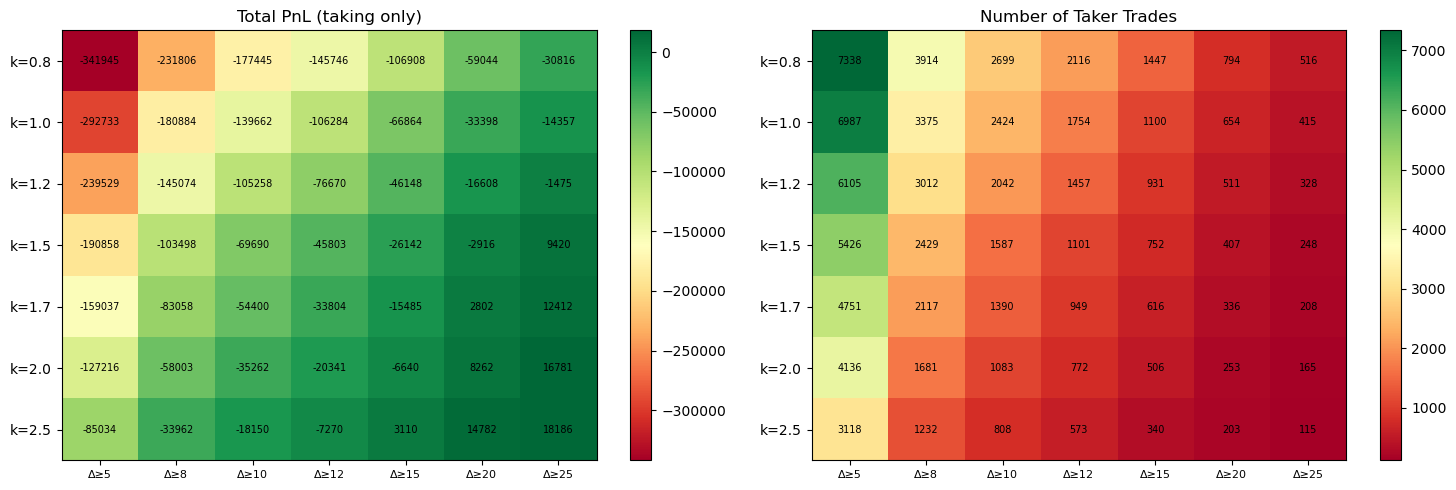

Best: k=2.5, threshold=25, PnL=18186, trades=115


In [14]:
TAKER_COST = 8  # half-spread cost per unit when crossing (spread ≈ 16)

def backtest(mid_prices, k, rebalance_threshold, taker_cost=TAKER_COST):
    position = 0
    cash = 0
    trade_count = 0
    entry_prices = {}  # position → avg entry price (for round-trip analysis)

    for price in mid_prices:
        raw_target = -POS_LIMIT * np.tanh((price - PACK_MEAN) / (k * PACK_STD))
        target = int(round(raw_target))
        delta = target - position

        if abs(delta) >= rebalance_threshold:
            # Pay taker cost: buying at ask (+cost), selling at bid (-cost)
            fill_price = price + np.sign(delta) * taker_cost
            cash -= delta * fill_price
            position = target
            trade_count += 1

    # Mark final position to mid
    final_pnl = cash + position * mid_prices[-1]
    return final_pnl, trade_count

mid_prices = pack['mid_price'].values

k_vals       = [0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5]
thresh_vals  = [5, 8, 10, 12, 15, 20, 25]

pnl_grid    = np.zeros((len(k_vals), len(thresh_vals)))
trade_grid  = np.zeros((len(k_vals), len(thresh_vals)))

for i, k in enumerate(k_vals):
    for j, thresh in enumerate(thresh_vals):
        pnl, ntrades = backtest(mid_prices, k, thresh)
        pnl_grid[i, j]   = pnl
        trade_grid[i, j] = ntrades

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, grid, title, fmt in zip(
    axes,
    [pnl_grid, trade_grid],
    ['Total PnL (taking only)', 'Number of Taker Trades'],
    ['{:.0f}', '{:.0f}'],
):
    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(thresh_vals)))
    ax.set_xticklabels([f'Δ≥{t}' for t in thresh_vals], fontsize=8)
    ax.set_yticks(range(len(k_vals)))
    ax.set_yticklabels([f'k={k}' for k in k_vals])
    ax.set_title(title)
    for ii in range(len(k_vals)):
        for jj in range(len(thresh_vals)):
            ax.text(jj, ii, fmt.format(grid[ii, jj]), ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Best combo
best_idx = np.unravel_index(np.argmax(pnl_grid), pnl_grid.shape)
print(f"Best: k={k_vals[best_idx[0]]}, threshold={thresh_vals[best_idx[1]]}, "
      f"PnL={pnl_grid[best_idx]:.0f}, trades={trade_grid[best_idx]:.0f}")

## PnL Trajectory + Inventory Evolution (best params)

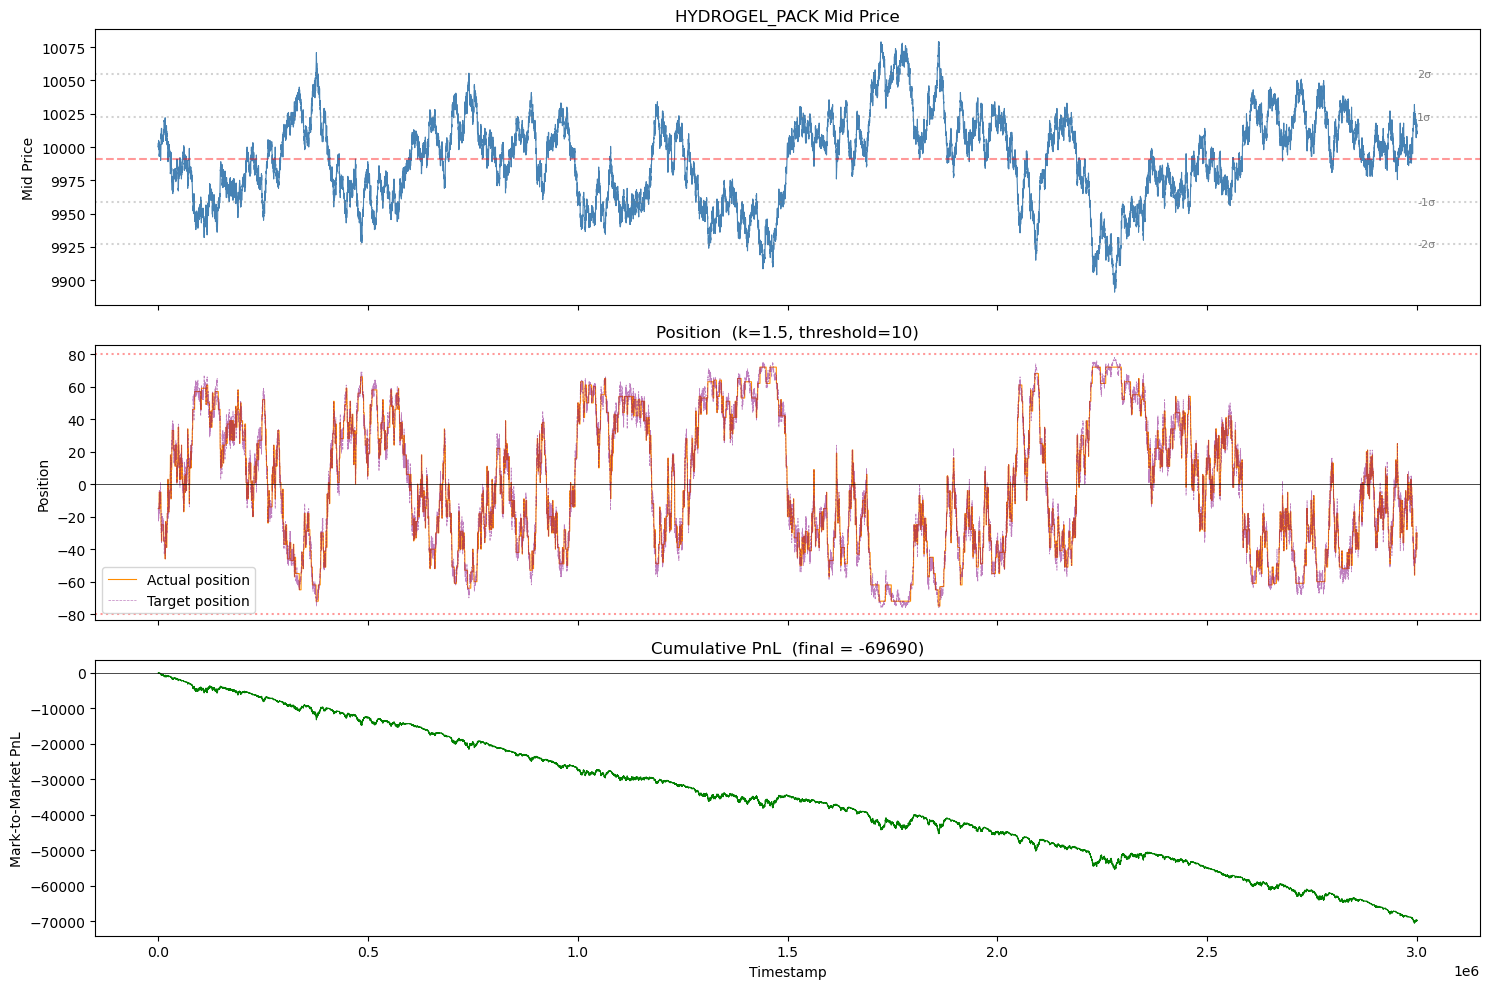

Day 0: PnL = -27390,  trades = 594
Day 1: PnL = -17302,  trades = 430
Day 2: PnL = -25017,  trades = 562


In [15]:
def backtest_trace(mid_prices, k, rebalance_threshold, taker_cost=TAKER_COST):
    """Full trace version for plotting."""
    position, cash = 0, 0
    positions, pnls, targets = [], [], []

    for price in mid_prices:
        raw_target = -POS_LIMIT * np.tanh((price - PACK_MEAN) / (k * PACK_STD))
        target = int(round(raw_target))
        delta = target - position

        if abs(delta) >= rebalance_threshold:
            fill_price = price + np.sign(delta) * taker_cost
            cash -= delta * fill_price
            position = target

        mtm_pnl = cash + position * price
        positions.append(position)
        pnls.append(mtm_pnl)
        targets.append(target)

    return np.array(positions), np.array(pnls), np.array(targets)

# Use a sensible candidate (adjust after seeing the sweep)
K_BEST     = 1.5
THRESH_BEST = 10

ts = pack['abs_ts'].values
positions, pnls, targets = backtest_trace(mid_prices, K_BEST, THRESH_BEST)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(ts, mid_prices, lw=0.8, color='steelblue')
axes[0].axhline(PACK_MEAN, color='red', linestyle='--', alpha=0.4)
for s in [-2, -1, 1, 2]:
    axes[0].axhline(PACK_MEAN + s * PACK_STD, color='gray', linestyle=':', alpha=0.35)
    axes[0].text(ts[-1], PACK_MEAN + s * PACK_STD, f'{s}σ', va='center', fontsize=8, color='gray')
axes[0].set_ylabel('Mid Price')
axes[0].set_title('HYDROGEL_PACK Mid Price')

axes[1].plot(ts, positions, color='darkorange', lw=0.8, label='Actual position')
axes[1].plot(ts, targets,   color='purple',     lw=0.5, alpha=0.5, linestyle='--', label='Target position')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axhline( POS_LIMIT, color='red', linestyle=':', alpha=0.4)
axes[1].axhline(-POS_LIMIT, color='red', linestyle=':', alpha=0.4)
axes[1].set_ylabel('Position')
axes[1].set_title(f'Position  (k={K_BEST}, threshold={THRESH_BEST})')
axes[1].legend()

axes[2].plot(ts, pnls, color='green', lw=0.8)
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_ylabel('Mark-to-Market PnL')
axes[2].set_xlabel('Timestamp')
axes[2].set_title(f'Cumulative PnL  (final = {pnls[-1]:.0f})')

plt.tight_layout()
plt.show()

# Per-day breakdown
day_boundaries = pack.groupby('day')['abs_ts'].agg(['min', 'max']).values
for day_idx, (t_min, t_max) in enumerate(day_boundaries):
    mask = (ts >= t_min) & (ts <= t_max)
    day_pnl = pnls[mask][-1] - pnls[mask][0]
    print(f"Day {day_idx}: PnL = {day_pnl:.0f},  trades = {(np.diff(positions[mask]) != 0).sum()}")

## Integration: How to wire this into market making

The taking strategy produces a `target_position` each tick. The market-making layer already has `max_allowed_buy_volume` / `max_allowed_sell_volume` which naturally encode position limits.

**Wire-up plan:**

```
target = -POS_LIMIT * tanh((fair_value - PACK_MEAN) / (K * PACK_STD))
delta  = target - self.position

if delta > REBALANCE_THRESHOLD:
    # aggressively take asks up to delta units (taker, no spread crossed in maker)
    take_volume = min(delta, self.max_allowed_buy_volume)
    self.bid(best_ask, take_volume)           # crosses spread → immediate fill

elif delta < -REBALANCE_THRESHOLD:
    take_volume = min(-delta, self.max_allowed_sell_volume)
    self.ask(best_bid, take_volume)

# then continue with normal maker quotes on top
```

The size-skew on bid/ask quotes (already coded) reinforces the signal passively while we wait for good passive fills, and the taking step fires only when we're meaningfully off-target.
```